# 01 - Exploring The WDBC Dataset
Before touching any leakage logic, let's just look at the dataset the whole
project is built on: the **Wisconsin Diagnostic Breast Cancer (WDBC)**
dataset, loaded straight from scikit-learn.

In [1]:
import sys
sys.path.insert(0, "../src")

import matplotlib.pyplot as plt
import seaborn as sns

from cancer_ml_leakage_demo.data import load_data

X, y = load_data()
print("Features shape:", X.shape)
print("Labels shape:", y.shape)
X.head()

Features shape: (569, 30)
Labels shape: (569,)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Class Balance
How many Malignant(1) VS Benign(0) casses are there?

In [2]:
counts = y.value_counts().sort_index()
percentages = (counts / counts.sum() * 100).round(1)

for label, count, pct in zip(counts.index, counts.values, percentages.values):
    name = "malignant" if label == 1 else "benign"
    print(f"{name}: {count} samples ({pct}%)")

benign: 357 samples (62.7%)
malignant: 212 samples (37.3%)


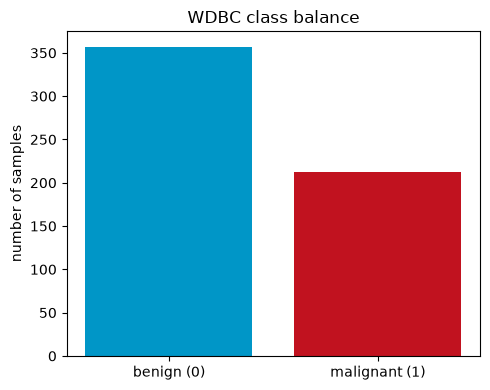

In [3]:
fig, ax = plt.subplots(figsize=(5, 4))
labels = ["benign (0)", "malignant (1)"]
ax.bar(labels, counts.values, color=["#0096C7", "#C1121F"])
ax.set_ylabel("number of samples")
ax.set_title("WDBC class balance")
fig.tight_layout()
fig.savefig("../results/figures/01_class_balance.png", dpi=150)
plt.show()

## Basic Statistics
A quick look at feature scales - notice how different features live on very different ranges (ex:- `area` vs `smoothness`).

In [4]:
X.describe().T[["mean", "std", "min", "max"]].round(2)

,mean,std,min,max
mean radius,14.13,3.52,6.98,28.11
mean texture,19.29,4.30,9.71,39.28
mean perimeter,91.97,24.30,43.79,188.50
mean area,654.89,351.91,143.50,2501.00
mean smoothness,0.10,0.01,0.05,0.16
mean compactness,0.10,0.05,0.02,0.35
mean concavity,0.09,0.08,0.00,0.43
mean concave points,0.05,0.04,0.00,0.20
mean symmetry,0.18,0.03,0.11,0.30
mean fractal dimension,0.06,0.01,0.05,0.10


## Feature Correlation
A lot of these 30 features are just mean/standard-error/worst versions of the same 10 underlying measurements, so we'd expect strong correlation among some of them.

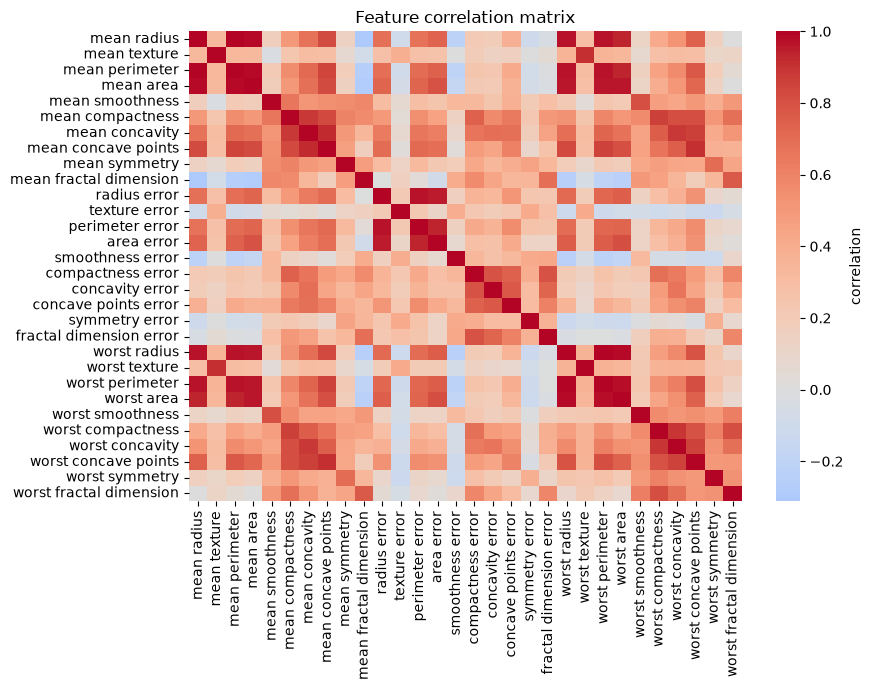

In [5]:
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(X.corr(), cmap="coolwarm", center=0, ax=ax, cbar_kws={"label": "correlation"})
ax.set_title("Feature correlation matrix")
fig.tight_layout()
fig.savefig("../results/figures/01_feature_correlation.png", dpi=150)
plt.show()

## Summary
* ~569 samples, 30 numeric features, one binary label. A small dataset -
  which is exactly why duplicating it is so easy to get away with, and
  exactly why a handful of leaked rows can swing accuracy so much.
* Classes are imbalanced (more benign than malignant), which is why every
  split in this project is **stratified**.
* Several features are highly correlated with each other, since they
  describe the same underlying measurement in different ways.

Next: `02_leaky_pipeline.ipynb` reproduces the paper's leakage bug.